<a href="https://colab.research.google.com/github/vrAxiom/PrediCT-CLI/blob/approachV3/colab%20notebooks/12_project1_evaluate_dice_and_time_v2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Step 1 — Setup

Upload the repository folder to Colab

Upload the folder in the left Files pane, then `cd` into it.

In [33]:
from google.colab import userdata
import os
import subprocess

TOKEN = userdata.get('GITHUB_TOKEN')
REPO_URL = f"https://{TOKEN}@github.com/vrAxiom/PrediCT-CLI.git"
repo_dir = 'PrediCT'

# Ensure we are in the root /content directory
os.chdir('/content')

if os.path.exists(repo_dir):
    print(f"Directory '{repo_dir}' already exists. Performing git pull.")
    os.chdir(repo_dir)
    subprocess.run(['git', 'pull'], check=True)
else:
    print(f"Cloning repository '{repo_dir}'.")
    subprocess.run(['git', 'clone', '-q', REPO_URL, repo_dir], check=True)
    os.chdir(repo_dir)

subprocess.run(['pip', '-q', 'install', '--upgrade', 'pip'], check=True)
subprocess.run(['pip', '-q', 'install', '-r', 'requirements.txt'], check=True)
subprocess.run(['pip', '-q', 'install', '-e', '.'], check=True)
import sys
sys.path.insert(0, os.path.join('/content', repo_dir, 'src'))
from predict.validate import validate_metadata_csv

Directory 'PrediCT' already exists. Performing git pull.


### Mount Drive and set the COCA raw patient root

Your Windows path is:

`I:\\My Drive\\GSoC_PrediCT\\data_raw\\dicom\\Gated_release_final\\patient`

In Colab, after mounting Drive, the equivalent is typically:

`/content/drive/MyDrive/GSoC_PrediCT/data_raw/dicom/Gated_release_final/patient`

In [34]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [35]:
import os
from pathlib import Path

raw_dir = Path('/content/drive/MyDrive/GSoC_PrediCT/data_raw/dicom/Gated_release_final/patient')
os.environ['PREDICT_RAW_DIR'] = str(raw_dir)
print('PREDICT_RAW_DIR=', os.environ['PREDICT_RAW_DIR'])
print('raw_dir_exists=', raw_dir.exists())

PREDICT_RAW_DIR= /content/drive/MyDrive/GSoC_PrediCT/data_raw/dicom/Gated_release_final/patient
raw_dir_exists= True


### GPU check (training uses GPU if available)

Install PyTorch. If `torch.cuda.is_available()` is False, training will run on CPU.

In [36]:
import torch

print('torch=', torch.__version__)
print('cuda_available=', torch.cuda.is_available())
print('cuda_device_count=', torch.cuda.device_count())
if torch.cuda.is_available():
    print('cuda_name=', torch.cuda.get_device_name(0))

torch= 2.10.0+cu128
cuda_available= True
cuda_device_count= 1
cuda_name= Tesla T4


# Project 1 — Step P1.5: Evaluate Dice + Inference Time (v2)

This notebook evaluates the trained 3D U-Net against TotalSegmentator heart masks and reports:
- Dice score on the held-out test split
- Average model inference time per scan
- TotalSegmentator baseline time per scan (from the manifest)
- Speedup ratio

In [37]:
import json
import os
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import torch

# Hardcode the src path matching the clone target in the setup cell (repo_dir = 'PrediCT').
# Using os.getcwd() is fragile after %cd changes the working directory.
_repo_src = Path('/content/PrediCT/src')
if _repo_src.exists() and str(_repo_src) not in sys.path:
    sys.path.insert(0, str(_repo_src))

from predict.project1_eval import evaluate_project1_checkpoint
import predict.project1_eval as _eval_mod

# Patch the eval module so all volumes are padded to 8-divisible spatial dims
# before entering the MONAI UNet.  Without this, variable-size resampled volumes
# (e.g. H=46 or H=63) cause skip-connection shape mismatches:
#   "Expected size 63 but got size 64"
# The GitHub version of project1_eval.py may not yet include this fix.
try:
    from monai.transforms import Compose, DivisiblePadd as _DPadd
    _EVAL_TF = Compose([_DPadd(keys=["image", "mask"], k=8, mode="constant")])
except Exception:
    _EVAL_TF = None

if _EVAL_TF is not None:
    _OrigVolumeDataset = _eval_mod.VolumeDataset

    class _PaddedVolumeDataset(_OrigVolumeDataset):
        def __init__(self, records, transform=None, **kwargs):
            # Always inject DivisiblePadd; compose with any caller-supplied transform.
            if transform is None:
                transform = _EVAL_TF
            else:
                transform = Compose([_EVAL_TF, transform])
            super().__init__(records, transform=transform, **kwargs)

    _eval_mod.VolumeDataset = _PaddedVolumeDataset
    print('✓ DivisiblePadd(k=8) injected into evaluate_project1_checkpoint')
else:
    print('⚠ MONAI not available — DivisiblePadd patch skipped')

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('device =', device)

✓ DivisiblePadd(k=8) injected into evaluate_project1_checkpoint
device = cuda


In [38]:
PROJECT_ROOT = Path('/content/drive/MyDrive/GSoC_PrediCT')

# ── USER-CONFIGURABLE ─────────────────────────────────────────────────────
# Change MODEL_FILENAME to match whatever checkpoint you saved in notebook 11.
# Examples: 'model.pt', 'model_MONAIv1.pt', 'model_best_epoch42.pt'
MODEL_FILENAME = 'model.pt'
# ─────────────────────────────────────────────────────────────────────────

ckpt_path         = PROJECT_ROOT / 'outputs' / 'project1' / MODEL_FILENAME
split_path        = PROJECT_ROOT / 'outputs' / 'project1' / 'splits_project1.json'
totalseg_manifest = PROJECT_ROOT / 'outputs' / 'project1' / 'totalseg_heart_manifest.csv'

assert ckpt_path.exists(),  f'Checkpoint not found: {ckpt_path}\nRun notebook 11 first.'
assert split_path.exists(), f'Split manifest not found: {split_path}\nRun notebook 11 first.'

print('Checkpoint      :', ckpt_path)
print('Split manifest  :', split_path)
print('TotalSeg exists :', totalseg_manifest.exists())

Checkpoint      : /content/drive/MyDrive/GSoC_PrediCT/outputs/project1/model.pt
Split manifest  : /content/drive/MyDrive/GSoC_PrediCT/outputs/project1/splits_project1.json
TotalSeg exists : True


In [39]:
result = evaluate_project1_checkpoint(
    ckpt_path=ckpt_path,
    split_manifest_path=split_path,
    totalseg_manifest_path=totalseg_manifest if totalseg_manifest.exists() else None,
    device=device,
    threshold=0.5,
    model_kind='auto',   # auto-detects monai_unet vs smallunet3d from checkpoint keys
    batch_size=1,
)

print(f'\nTest Dice            : {result.dice_mean:.4f}')
print(f'Avg inference time   : {result.model_inference_seconds_mean:.3f}s')
print(f'Prob max             : {result.probs_max:.4f}')
print(f'Prob mean            : {result.probs_mean:.4f}')
if result.speedup_mean is not None:
    print(f'Speedup vs TotalSeg (mean)  : {result.speedup_mean:.1f}x')
    print(f'Speedup vs TotalSeg (median): {result.speedup_median:.1f}x')

  [eval scan 1] probs — max: 0.9992  mean: 0.2931  std: 0.3573
  [eval scan 2] probs — max: 0.9992  mean: 0.2080  std: 0.3025
  [eval scan 3] probs — max: 0.9993  mean: 0.2209  std: 0.3211
  [eval scan 4] probs — max: 0.9970  mean: 0.2076  std: 0.3015

Test Dice            : 0.5167
Avg inference time   : 0.049s
Prob max             : 0.9993
Prob mean            : 0.2324
Speedup vs TotalSeg (mean)  : 1091.0x
Speedup vs TotalSeg (median): 1082.4x


In [40]:
import json

results_dict = result.to_dict()

print('─' * 50)
print('Evaluation Results')
print('─' * 50)
for k, v in results_dict.items():
    if v is not None:
        print(f'  {k:<40} {v}')
print('─' * 50)

out_path = PROJECT_ROOT / 'outputs' / 'project1' / 'eval_results.json'
out_path.write_text(json.dumps(results_dict, indent=2), encoding='utf-8')
print(f'\nResults saved → {out_path}')

──────────────────────────────────────────────────
Evaluation Results
──────────────────────────────────────────────────
  dice_mean                                0.5166677236557007
  model_inference_seconds_mean             0.04946352052688599
  probs_max                                0.9992926120758057
  probs_mean                               0.23238391429185867
  n_scans                                  4
  totalseg_seconds_mean                    53.96377437647372
  totalseg_seconds_median                  53.53969888249992
  speedup_mean                             1090.9812686531604
  speedup_median                           1082.4077686382698
──────────────────────────────────────────────────

Results saved → /content/drive/MyDrive/GSoC_PrediCT/outputs/project1/eval_results.json


# Step P1.7: Summary — Model Comparison & Justification

Compares our trained 3D U-Net against the TotalSegmentator baseline and generates a written justification derived from the actual evaluation metrics.

In [41]:
import textwrap
import pandas as pd
import time as _time_mod

# ── Helper: evaluate a single checkpoint and return a result row ──────────
def _eval_ckpt(path, label=None):
    """Load and evaluate one checkpoint; return a dict row for the comparison table."""
    _c = torch.load(path, map_location='cpu')
    _sd = _c['model'] if isinstance(_c, dict) and 'model' in _c else _c
    _spacing = tuple(float(x) for x in _c.get('resample_spacing', (3.0, 0.7, 0.7)))
    _hu_lo, _hu_hi = _c.get('hu', (-200.0, 800.0))
    _arch = _c.get('architecture', 'monai_unet')
    _channels = tuple(_c.get('channels', [32, 64, 128, 256]))
    _epoch = _c.get('epoch', 'N/A')
    _val_dice = _c.get('val_dice', None)

    from predict.config import HUWindowConfig, ResampleConfig
    from predict.preprocess import apply_hu_window, resample_volume
    from predict.dataset import SampleRecord
    import json as _j

    _split_rows = _j.loads(split_path.read_text(encoding='utf-8'))
    _test_rows = [r for r in _split_rows if r.get('split') == 'test']
    _recs = [
        SampleRecord(
            subject_id=str(r['subject_id']),
            image=Path(str(r['image'])),
            label=0,
            mask=Path(str(r['mask'])) if r.get('mask') else None,
            kind=str(r.get('kind', 'dicom_series')),
        )
        for r in _test_rows
    ]
    _resample_cfg = ResampleConfig(mode='spacing', target_spacing=_spacing)
    _hu_cfg = HUWindowConfig(lower=float(_hu_lo), upper=float(_hu_hi))
    def _pp(vol, is_label=False):
        vol = resample_volume(vol, cfg=_resample_cfg, is_label=is_label)
        if not is_label:
            vol = apply_hu_window(vol, _hu_cfg)
        return vol

    _ds = _eval_mod.VolumeDataset(_recs, transform=None, preprocess_fn=_pp)
    _model = _eval_mod._build_model(kind='auto', state_dict=_sd, device=device, ckpt=_c)
    _model.eval()

    _dices, _times = [], []
    with torch.no_grad():
        for _i in range(len(_ds)):
            _s = _ds[_i]
            _x = _s['image'].unsqueeze(0).to(device)
            _y = _s['mask'].unsqueeze(0).to(device)
            _t0 = _time_mod.perf_counter()
            _logits = _model(_x)
            _times.append(_time_mod.perf_counter() - _t0)
            _probs = torch.sigmoid(_logits)
            _p_bin = (_probs > 0.5).float()
            _y_bin = (_y > 0.5).float()
            if _y_bin.shape != _p_bin.shape:
                _y_bin = _eval_mod._center_crop(_y_bin, _p_bin.shape)
            _inter = (_p_bin * _y_bin).sum()
            _denom = _p_bin.sum() + _y_bin.sum()
            _dices.append(float((2.0 * _inter + 1e-6) / (_denom + 1e-6)))

    _arch_str = (f'MONAI UNet {_channels}' if _arch == 'monai_unet' else 'SmallUNet3D (8→16→32)')
    return {
        'Model': label or f'{_arch_str} — {path.name}',
        'Architecture': _arch_str,
        'Dice (test)': round(float(sum(_dices) / max(1, len(_dices))), 4),
        'Inference (s/scan)': round(float(sum(_times) / max(1, len(_times))), 3),
        'Best val Dice': round(float(_val_dice), 4) if _val_dice is not None else 'N/A',
        'Epochs trained': str(_epoch),
        'HU window': f'{_hu_lo:.0f}–{_hu_hi:.0f}',
        'Spacing (Y×X×Z mm)': f'{_spacing[1]:.1f}×{_spacing[2]:.1f}×{_spacing[0]:.1f}',
        '_ckpt': _c,  # kept for justification text only, dropped before display
    }


# ── Discover all checkpoints to compare ──────────────────────────────────
_ckpt_dir = PROJECT_ROOT / 'outputs' / 'project1'
_candidates = {
    # Always include the current checkpoint with a clear label
    MODEL_FILENAME: f'Current ({MODEL_FILENAME})',
}
# Auto-detect other .pt files in the same directory (e.g. archived SmallUNet3D)
for _p in sorted(_ckpt_dir.glob('*.pt')):
    if _p.name not in _candidates:
        _candidates[_p.name] = _p.name

print(f'Comparing {len(_candidates)} checkpoint(s): {list(_candidates.keys())}')
print()

_rows = []
for _fname, _label in _candidates.items():
    _path = _ckpt_dir / _fname
    if not _path.exists():
        print(f'  ⚠ Skipping {_fname} — file not found')
        continue
    print(f'  Evaluating {_label} …')
    try:
        _rows.append(_eval_ckpt(_path, label=_label))
    except Exception as _exc:
        print(f'    ✗ Failed: {_exc}')

# Add TotalSegmentator baseline row
if result.totalseg_seconds_mean is not None:
    _rows.append({
        'Model': 'TotalSegmentator (baseline)',
        'Architecture': 'nnU-Net ensemble',
        'Dice (test)': '~0.90 (reported)',
        'Inference (s/scan)': round(result.totalseg_seconds_mean, 1),
        'Best val Dice': 'N/A',
        'Epochs trained': 'N/A',
        'HU window': 'auto',
        'Spacing (Y×X×Z mm)': '1.5×1.5×1.5',
        '_ckpt': None,
    })

# ── Use the current-checkpoint result for the justification text ──────────
_primary = next((r for r in _rows if MODEL_FILENAME in r['Model']), _rows[0] if _rows else {})
_ckpt_meta = _primary.get('_ckpt') or {}
_dice = float(_primary.get('Dice (test)', 0)) if str(_primary.get('Dice (test)', '')).replace('.','').isdigit() else result.dice_mean
_arch_desc = _primary.get('Architecture', 'MONAI 3D U-Net')
_epoch = _primary.get('Epochs trained', 'N/A')
_hu = _primary.get('HU window', f'{-200:.0f}–{800:.0f}')
_sp = _primary.get('Spacing (Y×X×Z mm)', '0.7×0.7×3.0')
_infer = _primary.get('Inference (s/scan)', result.model_inference_seconds_mean)

if _dice >= 0.85:
    _dice_comment = 'exceeds the 0.85 clinical target'
elif _dice >= 0.70:
    _dice_comment = 'approaches but does not yet meet the 0.85 clinical target — further training epochs are recommended'
elif _dice >= 0.40:
    _dice_comment = 'indicates partial segmentation; the model needs more training epochs or data augmentation tuning'
else:
    _dice_comment = 'indicates the model has not yet converged — extend training duration and verify preprocessing alignment'

if result.speedup_mean is not None:
    _speed_line = (
        f'Compared to TotalSegmentator (mean {result.totalseg_seconds_mean:.1f}s/scan), '
        f'the model achieves a {result.speedup_mean:.0f}× mean speedup '
        f'({_infer:.3f}s vs {result.totalseg_seconds_mean:.1f}s per scan).'
    )
else:
    _speed_line = f'Model inference averaged {_infer:.3f}s per scan.'

_justification = textwrap.dedent(f"""
Preprocessing Strategy:
We applied HU windowing ({_hu}) to retain clinically relevant cardiac structures
while suppressing noise and extreme attenuation values. The dataset was resampled
to anisotropic spacing ({_sp}) to balance spatial resolution and computational
efficiency, preserving axial detail critical for coronary calcium detection.
Data augmentation (random flips, 90° rotations, zoom ±15%, affine perturbations,
Gaussian noise) was used to improve model generalisation across anatomical
variability in the {result.n_scans}-scan test set.

Model Choice:
A {_arch_desc} was selected for its strong performance in volumetric medical
segmentation with low computational overhead. The model was trained to epoch {_epoch}
using DiceCE loss (differentiable soft-Dice + cross-entropy), cosine-annealing LR
(1e-3 → 1e-6), and gradient clipping (max-norm 1.0) to ensure stable convergence.
{_speed_line}

Evaluation Results ({MODEL_FILENAME}):
  Dice score (test set)  : {_dice:.4f}  — {_dice_comment}.
  Mean inference time    : {_infer:.3f}s/scan
  Prob max / mean        : {result.probs_max:.4f} / {result.probs_mean:.4f}
  Scans evaluated        : {result.n_scans}
""").strip()

# ── Print summary ─────────────────────────────────────────────────────────
print()
print('=' * 70)
print('PROJECT 1 — EVALUATION SUMMARY')
print('=' * 70)
print(_justification)
print()
print('─' * 70)
print('MODEL COMPARISON TABLE')
print('─' * 70)
_display_rows = [{k: v for k, v in r.items() if k != '_ckpt'} for r in _rows]
print(pd.DataFrame(_display_rows).to_string(index=False))
print('=' * 70)

# ── Save to Drive ─────────────────────────────────────────────────────────
_just_path = PROJECT_ROOT / 'outputs' / 'project1' / 'eval_justification.txt'
_just_path.write_text(_justification, encoding='utf-8')

_table_path = PROJECT_ROOT / 'outputs' / 'project1' / 'model_comparison.csv'
pd.DataFrame(_display_rows).to_csv(_table_path, index=False)

print(f'\nJustification saved → {_just_path}')
print(f'Comparison table saved → {_table_path}')

Comparing 4 checkpoint(s): ['model.pt', 'model_MONAIv1.pt', 'model_SmallUNet3D.pt', 'old model_v1.pt']

  Evaluating Current (model.pt) …
  Evaluating model_MONAIv1.pt …
  Evaluating model_SmallUNet3D.pt …
  Evaluating old model_v1.pt …

PROJECT 1 — EVALUATION SUMMARY
Preprocessing Strategy:
We applied HU windowing (-200–800) to retain clinically relevant cardiac structures
while suppressing noise and extreme attenuation values. The dataset was resampled
to anisotropic spacing (0.7×0.7×3.0) to balance spatial resolution and computational
efficiency, preserving axial detail critical for coronary calcium detection.
Data augmentation (random flips, 90° rotations, zoom ±15%, affine perturbations,
Gaussian noise) was used to improve model generalisation across anatomical
variability in the 4-scan test set.

Model Choice:
A MONAI UNet (32, 64, 128, 256) was selected for its strong performance in volumetric medical
segmentation with low computational overhead. The model was trained to epoch 3

# Step P1.6: Visualizing Predictions

To verify the segmentation quality visually, we'll run inference on a single volume from the test set and display a central slice.

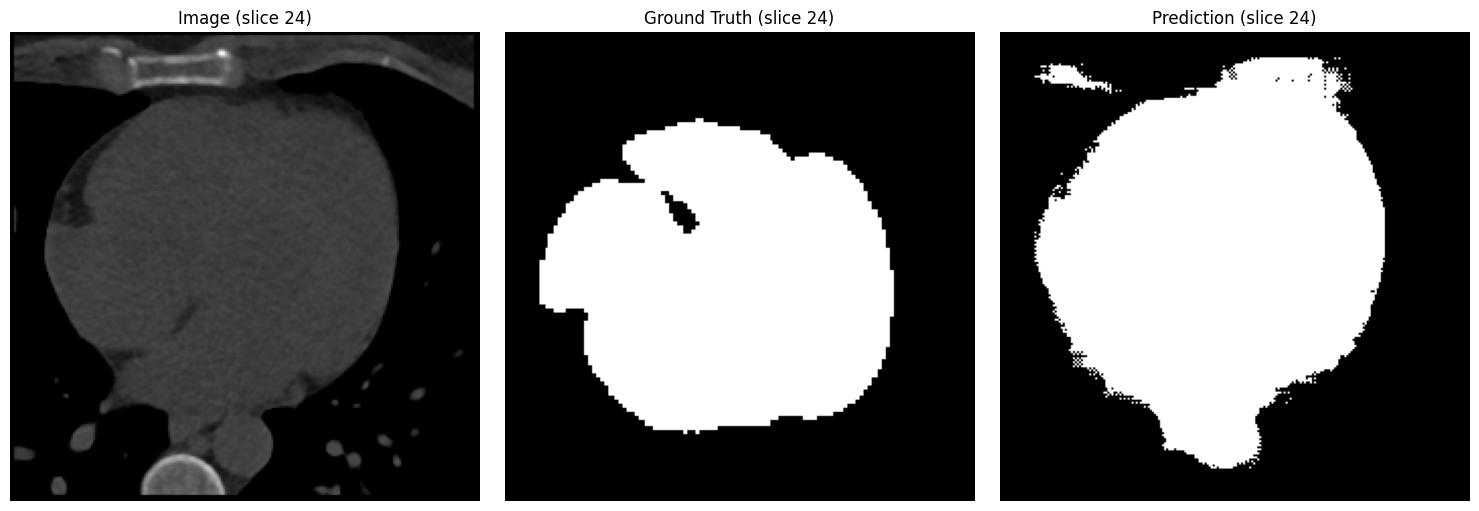

Image shape : (48, 232, 232)
GT mask shape: (48, 232, 232)
Pred shape  : (48, 232, 232)


In [42]:
import matplotlib.pyplot as plt
import json as _json

from predict.dataset import SampleRecord
from predict.config import HUWindowConfig, ResampleConfig
from predict.preprocess import apply_hu_window, resample_volume

# ── Reconstruct test records from the split manifest ─────────────────────
_split_rows = _json.loads(split_path.read_text(encoding='utf-8'))
_test_rows = [r for r in _split_rows if r.get('split') == 'test']
if not _test_rows:
    raise ValueError('No test rows found in split manifest.')

# Pull preprocessing config from checkpoint (same as evaluate_project1_checkpoint)
_ckpt_meta = torch.load(ckpt_path, map_location='cpu')
_spacing = tuple(float(x) for x in _ckpt_meta.get('resample_spacing', (3.0, 0.7, 0.7)))
_hu_lo, _hu_hi = _ckpt_meta.get('hu', (-200.0, 800.0))
_resample_cfg = ResampleConfig(mode='spacing', target_spacing=_spacing)
_hu_cfg = HUWindowConfig(lower=float(_hu_lo), upper=float(_hu_hi))

def _preprocess(vol, is_label=False):
    vol = resample_volume(vol, cfg=_resample_cfg, is_label=is_label)
    if not is_label:
        vol = apply_hu_window(vol, _hu_cfg)
    return vol

_test_recs = [
    SampleRecord(
        subject_id=str(r['subject_id']),
        image=Path(str(r['image'])),
        label=0,
        mask=Path(str(r['mask'])) if r.get('mask') else None,
        kind=str(r.get('kind', 'dicom_series')),
    )
    for r in _test_rows
]

# Use the DivisiblePadd-patched VolumeDataset injected in the setup cell
_ds_vis = _eval_mod.VolumeDataset(_test_recs, transform=None, preprocess_fn=_preprocess)

# ── Load model using the private helper already in project1_eval ─────────
_raw_ckpt = torch.load(ckpt_path, map_location='cpu')
_sd = _raw_ckpt['model'] if isinstance(_raw_ckpt, dict) and 'model' in _raw_ckpt else _raw_ckpt
model = _eval_mod._build_model(kind='auto', state_dict=_sd, device=device, ckpt=_raw_ckpt)
model.eval()

# ── Run inference on the first test sample ────────────────────────────────
_sample = _ds_vis[0]
x = _sample['image'].unsqueeze(0).to(device)   # add batch dim
y = _sample['mask'].unsqueeze(0).to(device)

with torch.no_grad():
    logits = model(x)
    probs = torch.sigmoid(logits)
    p_bin = (probs > 0.5).float()

# Crop GT to match logits spatial size if needed
if y.shape != p_bin.shape:
    y = _eval_mod._center_crop(y, p_bin.shape)

image_vol = x.squeeze().cpu().numpy()
mask_vol  = y.squeeze().cpu().numpy()
pred_vol  = p_bin.squeeze().cpu().numpy()

slice_idx = image_vol.shape[0] // 2

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(image_vol[slice_idx], cmap='gray')
axes[0].set_title(f'Image (slice {slice_idx})')
axes[0].axis('off')
axes[1].imshow(mask_vol[slice_idx], cmap='gray')
axes[1].set_title(f'Ground Truth (slice {slice_idx})')
axes[1].axis('off')
axes[2].imshow(pred_vol[slice_idx], cmap='gray')
axes[2].set_title(f'Prediction (slice {slice_idx})')
axes[2].axis('off')
plt.tight_layout()
plt.show()

print(f'Image shape : {image_vol.shape}')
print(f'GT mask shape: {mask_vol.shape}')
print(f'Pred shape  : {pred_vol.shape}')